✅ تعداد رکوردهای تجمیع‌شده: 73

🚨 تعداد شیفت‌های دارای خطای موازنه آهن بیش از ۵ درصد: 0


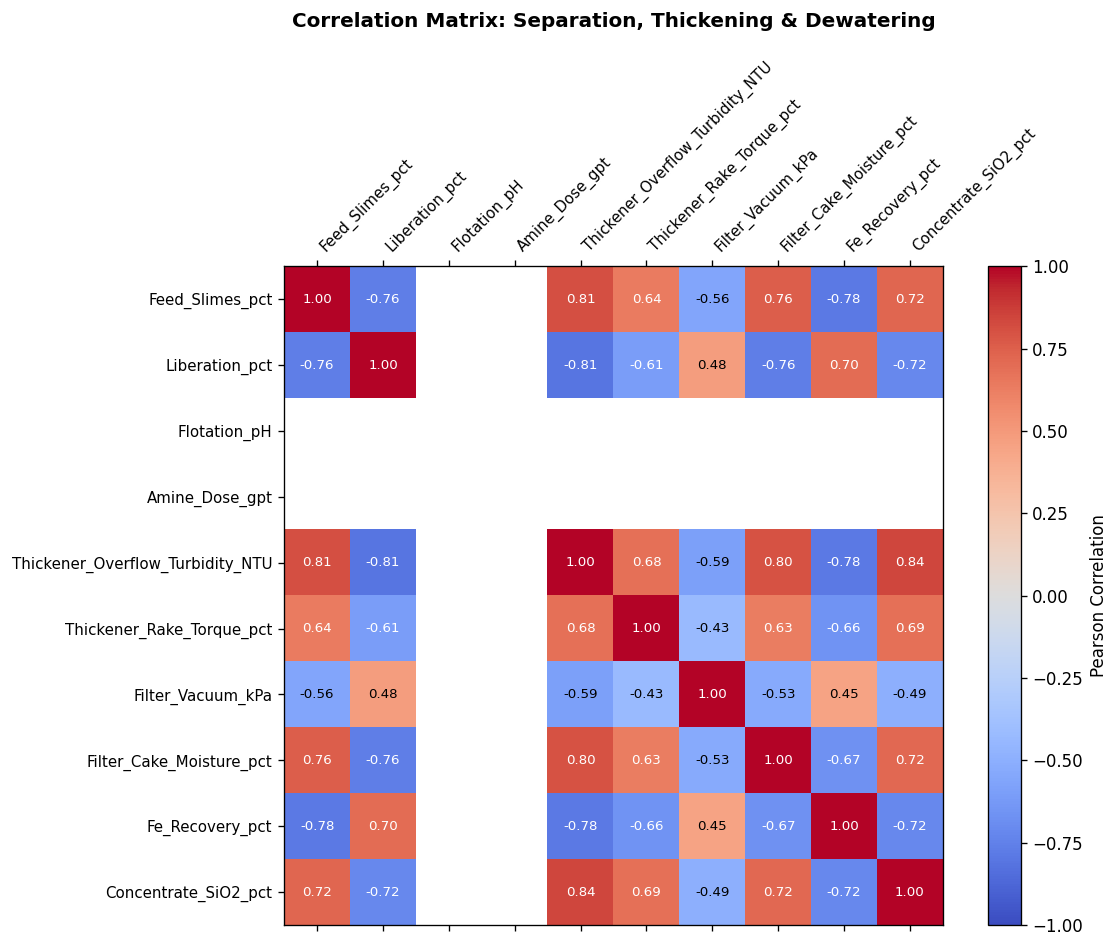

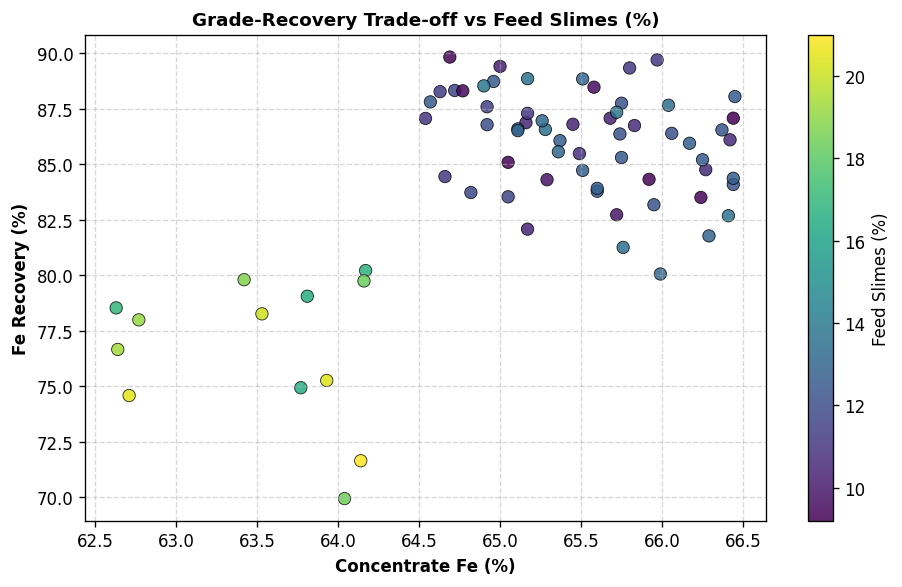

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. مسیر فایل اکسل (در محیط محلی خودت مسیر رو تنظیم کن)
file_path = "/home/qc/داده آموزشی فصل ۳ فرآوری — جدایش مغناطیسی، فلوتاسیون، تیکنر و کیک فیلتر_1790944631687.xlsx"

# بارگذاری شیت‌های فرآیند و آبگیری/موازنه
df_process = pd.read_excel(file_path, sheet_name="Process_Data")
df_dewater = pd.read_excel(file_path, sheet_name="Dewatering_Balance")

# ادغام بر اساس Record_ID
df = pd.merge(
    df_process,
    df_dewater,
    on="Record_ID",
    how="inner",
    suffixes=("", "_dewater"),
)

print(f"✅ تعداد رکوردهای تجمیع‌شده: {len(df)}")

# 2. بررسی ستون‌های مورد نیاز
required_columns = [
    "DateTime",
    "Shift",
    "Feed_Fe_pct",
    "Concentrate_Fe_pct",
    "Fe_Balance_Error_pct",
    "Feed_Slimes_pct",
    "Liberation_pct",
    "Flotation_pH",
    "Amine_Dose_gpt",
    "Thickener_Overflow_Turbidity_NTU",
    "Thickener_Rake_Torque_pct",
    "Filter_Vacuum_kPa",
    "Filter_Cake_Moisture_pct",
    "Fe_Recovery_pct",
    "Concentrate_SiO2_pct",
]

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"ستون‌های زیر یافت نشدند: {missing_columns}")

# 3. غربالگری خطای موازنه آهن (Fe Balance Error > 5%)
anomalies = df[df["Fe_Balance_Error_pct"].abs() > 5.0].copy()

print(
    f"\n🚨 تعداد شیفت‌های دارای خطای موازنه آهن بیش از ۵ درصد: {len(anomalies)}"
)
if not anomalies.empty:
    print(
        anomalies[
            [
                "DateTime",
                "Shift",
                "Feed_Fe_pct",
                "Concentrate_Fe_pct",
                "Fe_Balance_Error_pct",
            ]
        ]
    )

# 4. ماتریس همبستگی (Correlation Heatmap)
key_vars = [
    "Feed_Slimes_pct",
    "Liberation_pct",
    "Flotation_pH",
    "Amine_Dose_gpt",
    "Thickener_Overflow_Turbidity_NTU",
    "Thickener_Rake_Torque_pct",
    "Filter_Vacuum_kPa",
    "Filter_Cake_Moisture_pct",
    "Fe_Recovery_pct",
    "Concentrate_SiO2_pct",
]

corr_matrix = df[key_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8), dpi=120)
cax = ax.matshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax, label="Pearson Correlation")

ax.set_xticks(range(len(key_vars)))
ax.set_yticks(range(len(key_vars)))
ax.set_xticklabels(key_vars, rotation=45, ha="left", fontsize=9)
ax.set_yticklabels(key_vars, fontsize=9)

for i in range(len(key_vars)):
    for j in range(len(key_vars)):
        val = corr_matrix.iloc[i, j]
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color="black" if -0.6 < val < 0.6 else "white",
            fontsize=8,
        )

ax.set_title(
    "Correlation Matrix: Separation, Thickening & Dewatering\n",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("correlation_matrix_ch03.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. نمودار Trade-off عیار - بازیابی آهن (رنگ‌آمیزی با اسلایم خوراک)
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

scatter = ax.scatter(
    df["Concentrate_Fe_pct"],
    df["Fe_Recovery_pct"],
    c=df["Feed_Slimes_pct"],
    cmap="viridis",
    s=55,
    alpha=0.85,
    edgecolor="k",
    linewidth=0.5,
)

ax.set_xlabel("Concentrate Fe (%)", fontsize=10, fontweight="bold")
ax.set_ylabel("Fe Recovery (%)", fontsize=10, fontweight="bold")
ax.set_title(
    "Grade-Recovery Trade-off vs Feed Slimes (%)", fontsize=11, fontweight="bold"
)
ax.grid(True, linestyle="--", alpha=0.5)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Feed Slimes (%)", fontsize=10)

plt.tight_layout()
plt.savefig("grade_recovery_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()
